# Interest-Rate Forecast and 10-Year Borrowing Capacity Projection

## Notebook Purpose

This notebook extends the mortgage loan prediction model developed in 2_Modeling_Evaluation.

The goal is to combine:

1. The trained mortgage loan limit prediction model
2. Historical 30-year fixed mortgage-rate data
3. User-provided future financial assumptions

to forecast a user's predicted maximum mortgage loan amount over the next 10 years.

The final output is a 10-year projection chart showing how a user's borrowing capacity may change over time.

In [34]:
# Set_Up
import json
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [35]:
# Define file paths
RATE_DATA_PATH = Path("MORTGAGE30US-2.csv")
MODEL_PATH = Path("outputs/models/best_mortgage_loan_model.joblib")
METADATA_PATH = Path("outputs/models/model_metadata.json")
OUTPUT_DIR = Path("outputs")
PLOTS_DIR = OUTPUT_DIR / "plots"
REPORTS_DIR = OUTPUT_DIR / "projection_reports"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Expected interest-rate data file:")
print(RATE_DATA_PATH.resolve())

print("\nExpected trained model file:")
print(MODEL_PATH.resolve())

print("\nExpected model metadata file:")
print(METADATA_PATH.resolve())

Expected interest-rate data file:
/Users/ziyang/anaconda_projects/Berkeley ML_AI Learning/Module 24/example/MORTGAGE30US-2.csv

Expected trained model file:
/Users/ziyang/anaconda_projects/Berkeley ML_AI Learning/Module 24/example/outputs/models/best_mortgage_loan_model.joblib

Expected model metadata file:
/Users/ziyang/anaconda_projects/Berkeley ML_AI Learning/Module 24/example/outputs/models/model_metadata.json


## Load Trained Mortgage Loan Model

In [36]:
# Load trained model and metadata
best_model = load(MODEL_PATH)

with open(METADATA_PATH, "r") as f:
    model_metadata = json.load(f)

target = model_metadata["target"]
feature_columns = model_metadata["feature_columns"]
best_model_name = model_metadata["best_model_name"]
category_options = model_metadata["category_options"]

print("Loaded model successfully.")
print(f"Best model: {best_model_name}")
print(f"Target variable: {target}")
print(f"Number of model input features: {len(feature_columns)}")

Loaded model successfully.
Best model: Gradient Boosting Regressor
Target variable: Max Loan Amount (USD)
Number of model input features: 20


In [37]:
feature_columns

['Gender',
 'Age',
 'Married',
 'Education',
 'Job',
 'Employment Years',
 'Annual Income (USD)',
 'Interest Rate',
 'Down Payment (USD)',
 'Credit Score',
 'Existing Monthly Debt (USD)',
 'Area',
 'Loans Repaid',
 'Debt to Income Ratio',
 'Available Annual Income (USD)',
 'Down Payment to Income Ratio',
 'Employment Stability Ratio',
 'Loan Repayment Rate',
 'Credit Score Category',
 'Income Category']

## Load Historical 30-Year Fixed Mortgage Rate Data

The historical mortgage-rate data comes from the FRED 30-Year Fixed Rate Mortgage Average series.

The uploaded file contains two columns:

- **observation_date**
- **MORTGAGE30US**

In [38]:
# Load historical mortgage-rate data
rate_df = pd.read_csv(RATE_DATA_PATH)
print(f"Rows: {rate_df.shape[0]:,}")
print(f"Columns: {rate_df.shape[1]:,}")
rate_df.head()

Rows: 1,587
Columns: 2


,observation_date,MORTGAGE30US
0,1996-01-05,7.02
1,1996-01-12,7.08
2,1996-01-19,7.02
3,1996-01-26,7.00
4,1996-02-02,7.02


In [39]:
rate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1587 entries, 0 to 1586
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  1587 non-null   object 
 1   MORTGAGE30US      1587 non-null   float64
dtypes: float64(1), object(1)
memory usage: 24.9+ KB


In [40]:
# Clean
rate_df = rate_df.copy()

rate_df["observation_date"] = pd.to_datetime(rate_df["observation_date"])
rate_df["MORTGAGE30US"] = pd.to_numeric(rate_df["MORTGAGE30US"], errors="coerce")

rate_df = rate_df.dropna()
rate_df = rate_df.sort_values("observation_date")

print("Date range:")
print(rate_df["observation_date"].min())
print(rate_df["observation_date"].max())

print("\nRate summary:")
display(rate_df["MORTGAGE30US"].describe())

rate_df.head()

Date range:
1996-01-05 00:00:00
2026-05-28 00:00:00

Rate summary:


count   1,587.00
mean        5.51
std         1.51
min         2.65
25%         4.10
50%         5.79
75%         6.75
max         8.64
Name: MORTGAGE30US, dtype: float64

,observation_date,MORTGAGE30US
0,1996-01-05,7.02
1,1996-01-12,7.08
2,1996-01-19,7.02
3,1996-01-26,7.00
4,1996-02-02,7.02


In [41]:
rate_df = rate_df.rename(
    columns={
        "observation_date": "Date",
        "MORTGAGE30US": "Mortgage Rate Percent"
    }
)

rate_df.head()

,Date,Mortgage Rate Percent
0,1996-01-05,7.02
1,1996-01-12,7.08
2,1996-01-19,7.02
3,1996-01-26,7.00
4,1996-02-02,7.02


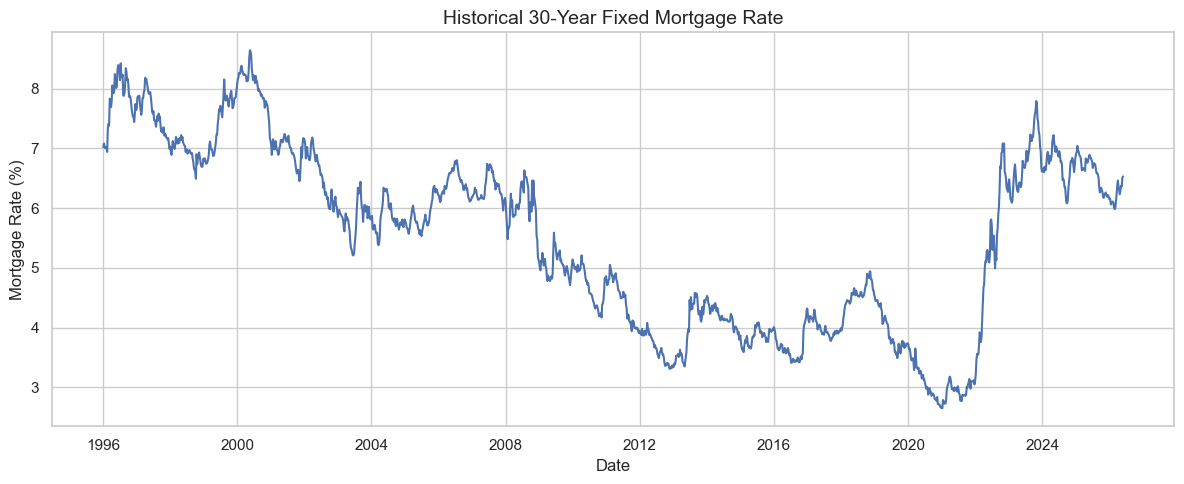

In [42]:
# Plot historical mortgage rate
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=rate_df,
    x="Date",
    y="Mortgage Rate Percent"
)
plt.title("Historical 30-Year Fixed Mortgage Rate", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Mortgage Rate (%)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "18_historical_mortgage_rate.png", dpi=300)
plt.show()

In [43]:
# Resample weekly rates to monthly average
monthly_rates = (
    rate_df
    .set_index("Date")["Mortgage Rate Percent"]
    .resample("M")
    .mean()
    .interpolate()
)

monthly_rates = monthly_rates.to_frame(name="Mortgage Rate Percent")
monthly_rates.head()

,Mortgage Rate Percent
Date,
1996-01-31,7.03
1996-02-29,7.08
1996-03-31,7.62
1996-04-30,7.93
1996-05-31,8.07


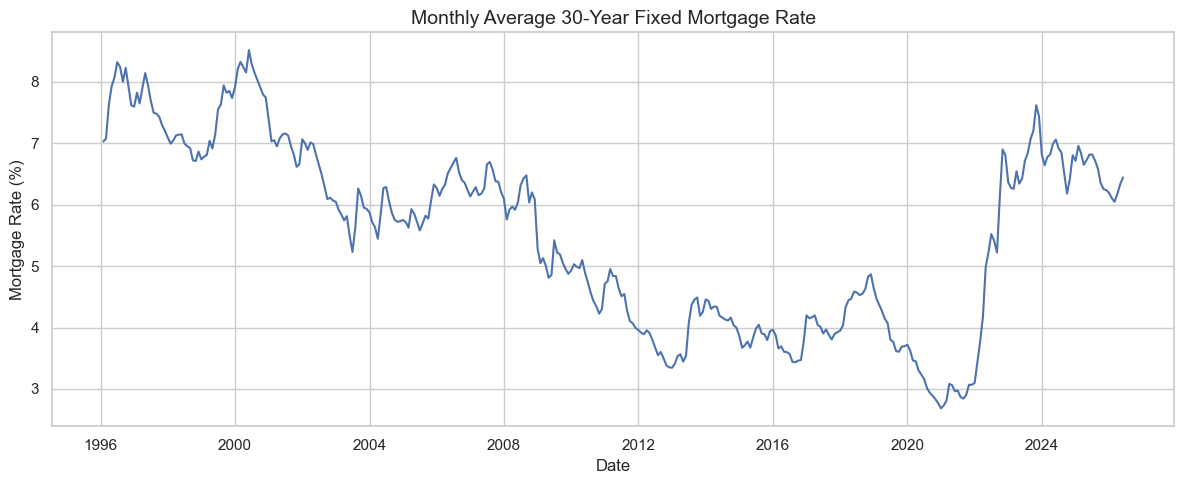

In [69]:
# Plot in monthly-smoothed scale
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_rates,
    x=monthly_rates.index,
    y="Mortgage Rate Percent"
)

plt.title("Monthly Average 30-Year Fixed Mortgage Rate", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Mortgage Rate (%)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "19_monthly_average_mortgage_rate.png", dpi=300)
plt.show()

## Time-Series

In [70]:
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_months = 10 * 12
rate_col = "Mortgage Rate Percent"

monthly_rates = monthly_rates.sort_index()
rate_series = monthly_rates[rate_col].dropna()

last_date = rate_series.index.max()
forecast_index = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=forecast_months,
    freq="ME"
)
recent_months = 36
rolling_average_rate = rate_series.tail(recent_months).mean()

rolling_forecast = pd.Series(
    data=rolling_average_rate,
    index=forecast_index,
    name="Rolling Average Forecast"
)

print(
    f"Rolling average rate based on last {recent_months} months: "
    f"{rolling_average_rate:.2f}%"
)
try:
    smoothing_model = ExponentialSmoothing(
        rate_series,
        trend="add",
        seasonal=None,
        damped_trend=True
    )

    smoothing_fit = smoothing_model.fit(optimized=True)
    central_forecast = smoothing_fit.forecast(forecast_months)

    central_forecast.index = forecast_index
    central_forecast.name = "Central Trend Forecast"
    central_forecast = central_forecast.clip(lower=1.0, upper=12.0)

    print("Exponential Smoothing central trend fitted successfully.")

except Exception as error:
    print("Exponential Smoothing failed.")
    print(error)
    print("Using rolling average forecast as central trend fallback.")

    central_forecast = rolling_forecast.copy()
    central_forecast.name = "Central Trend Forecast"

smoothing_forecast = central_forecast.copy()
smoothing_forecast.name = "Exponential Smoothing Forecast"

central_forecast.head()


Rolling average rate based on last 36 months: 6.68%
Exponential Smoothing central trend fitted successfully.


2026-06-30   6.47
2026-07-31   6.49
2026-08-31   6.51
2026-09-30   6.52
2026-10-31   6.53
Freq: ME, Name: Central Trend Forecast, dtype: float64

In [71]:
lookback_months = 120

historical_monthly_changes = (
    rate_series
    .diff()
    .dropna()
    .tail(lookback_months)
)

change_mean = historical_monthly_changes.mean()
historical_shocks = historical_monthly_changes - change_mean

change_cap = historical_monthly_changes.abs().quantile(0.95)

print(f"Historical monthly change mean: {change_mean:.3f}%")
print(f"Historical monthly change std:  {historical_monthly_changes.std():.3f}%")
print(f"Monthly change cap used:        {change_cap:.3f}%")

# Reproducible simulation
np.random.seed(42)

sampled_shocks = np.random.choice(
    historical_shocks.values,
    size=forecast_months,
    replace=True
)

fluctuating_rates = []

current_rate = rate_series.iloc[-1]
previous_change = historical_monthly_changes.iloc[-1]

# Tuning parameters
pull_strength = 0.08      # Pulls the path back toward the central trend
momentum_strength = 0.35  # Preserves short-term directional movement
shock_scale = 0.90        # Controls the size of random historical-style fluctuation

for i in range(forecast_months):
    target_rate = central_forecast.iloc[i]
    random_shock = sampled_shocks[i] * shock_scale

    simulated_change = (
        pull_strength * (target_rate - current_rate)
        + momentum_strength * previous_change
        + random_shock
    )

    simulated_change = np.clip(
        simulated_change,
        -change_cap,
        change_cap
    )

    current_rate = current_rate + simulated_change
    current_rate = np.clip(current_rate, 1.0, 12.0)

    fluctuating_rates.append(current_rate)
    previous_change = simulated_change

fluctuating_forecast = pd.Series(
    data=fluctuating_rates,
    index=forecast_index,
    name="Fluctuating Forecast Path"
)

fluctuating_forecast.head()


Historical monthly change mean: 0.024%
Historical monthly change std:  0.216%
Monthly change cap used:        0.420%


2026-06-30   6.38
2026-07-31   6.31
2026-08-31   6.39
2026-09-30   6.34
2026-10-31   6.38
Freq: ME, Name: Fluctuating Forecast Path, dtype: float64

In [72]:
forecast_comparison_df = pd.DataFrame({
    "Rolling Average Forecast": rolling_forecast,
    "Exponential Smoothing Forecast": smoothing_forecast,
    "Fluctuating Forecast Path": fluctuating_forecast
})

forecast_comparison_df.head()


,Rolling Average Forecast,Exponential Smoothing Forecast,Fluctuating Forecast Path
2026-06-30,6.68,6.47,6.38
2026-07-31,6.68,6.49,6.31
2026-08-31,6.68,6.51,6.39
2026-09-30,6.68,6.52,6.34
2026-10-31,6.68,6.53,6.38


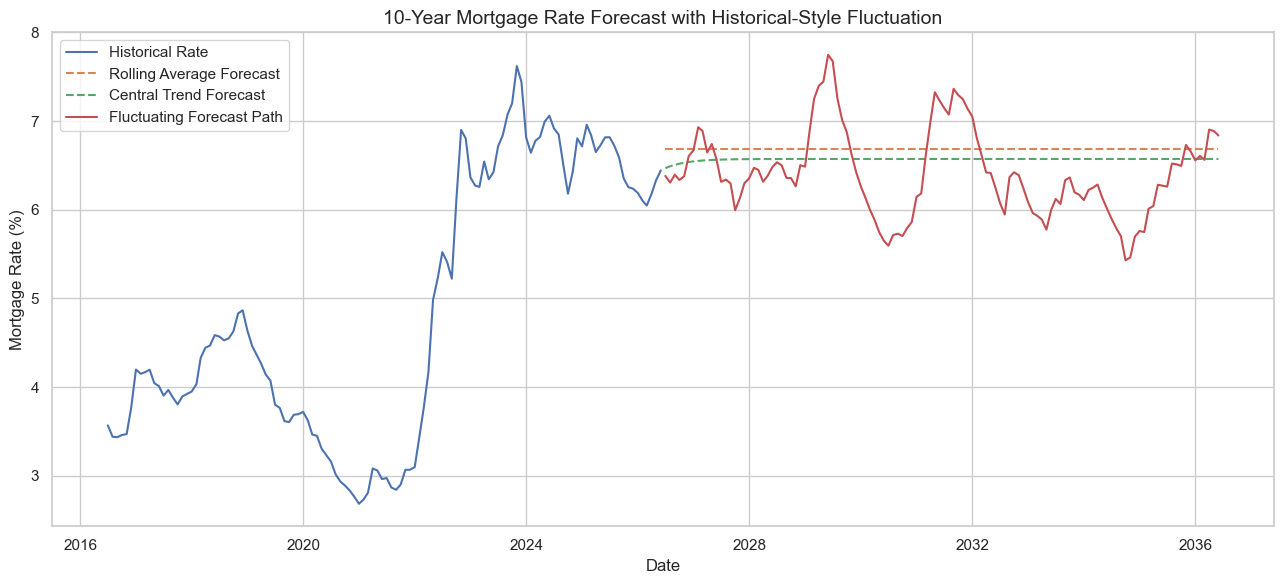

In [73]:
# Plot historical monthly rates and forecast scenarios
plt.figure(figsize=(13, 6))

recent_history = monthly_rates.tail(120)

sns.lineplot(
    x=recent_history.index,
    y=recent_history["Mortgage Rate Percent"],
    label="Historical Rate"
)

sns.lineplot(
    x=rolling_forecast.index,
    y=rolling_forecast.values,
    linestyle="--",
    label="Rolling Average Forecast"
)

sns.lineplot(
    x=smoothing_forecast.index,
    y=smoothing_forecast.values,
    linestyle="--",
    label="Central Trend Forecast"
)

sns.lineplot(
    x=fluctuating_forecast.index,
    y=fluctuating_forecast.values,
    label="Fluctuating Forecast Path"
)

plt.title("10-Year Mortgage Rate Forecast with Historical-Style Fluctuation", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Mortgage Rate (%)")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "20_mortgage_rate_forecast_scenarios.png", dpi=300)
plt.show()


In [74]:
# Select final forecast scenario
selected_monthly_forecast = fluctuating_forecast.copy()
selected_monthly_forecast.name = "Selected Mortgage Rate Forecast"
selected_monthly_forecast.head()

2026-06-30   6.38
2026-07-31   6.31
2026-08-31   6.39
2026-09-30   6.34
2026-10-31   6.38
Freq: ME, Name: Selected Mortgage Rate Forecast, dtype: float64

## Convert Monthly Forecast Into 10 Annual Projection Years

In [75]:
forecast_table = pd.DataFrame({
    "Forecast Date": selected_monthly_forecast.index,
    "Forecast Mortgage Rate Percent": selected_monthly_forecast.values
})

forecast_table["Projection Year"] = (np.arange(len(forecast_table)) // 12) + 1

annual_rate_forecast = (
    forecast_table
    .groupby("Projection Year")["Forecast Mortgage Rate Percent"]
    .mean()
    .reset_index()
)

annual_rate_forecast["Forecast Interest Rate"] = (
    annual_rate_forecast["Forecast Mortgage Rate Percent"] / 100
)

# Calendar year label based on last historical date
start_year = rate_df["Date"].max().year + 1
annual_rate_forecast["Calendar Year"] = start_year + annual_rate_forecast["Projection Year"] - 1

annual_rate_forecast = annual_rate_forecast[
    [
        "Projection Year",
        "Calendar Year",
        "Forecast Mortgage Rate Percent",
        "Forecast Interest Rate"
    ]
]

annual_rate_forecast

,Projection Year,Calendar Year,Forecast Mortgage Rate Percent,Forecast Interest Rate
0,1,2027,6.57,0.07
1,2,2028,6.32,0.06
2,3,2029,6.81,0.07
3,4,2030,6.46,0.06
4,5,2031,6.24,0.06
5,6,2032,6.90,0.07
6,7,2033,6.09,0.06
7,8,2034,6.19,0.06
8,9,2035,5.84,0.06
9,10,2036,6.63,0.07


In [76]:
forecast_output_path = REPORTS_DIR / "ten_year_mortgage_rate_forecast.csv"
annual_rate_forecast.to_csv(forecast_output_path, index=False)
print(f"10-year mortgage-rate forecast saved to: {forecast_output_path}")

10-year mortgage-rate forecast saved to: outputs/projection_reports/ten_year_mortgage_rate_forecast.csv


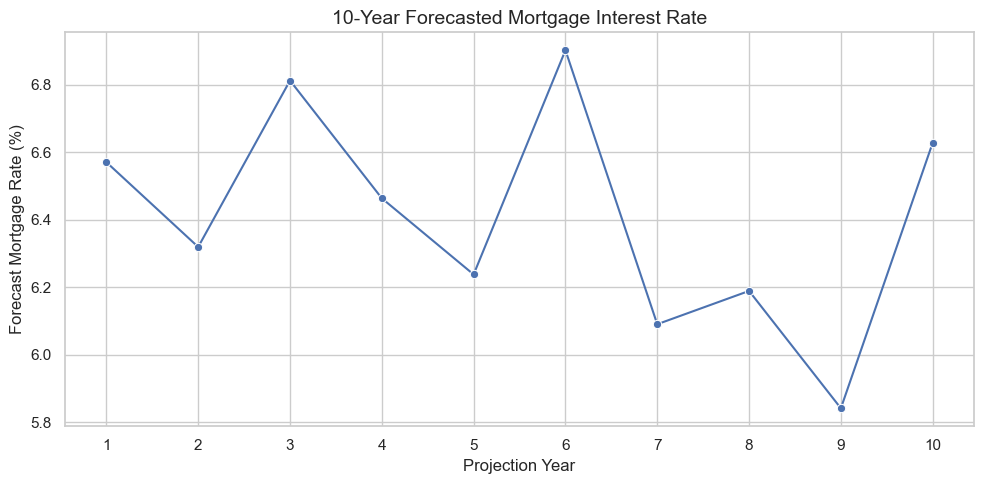

In [77]:
# Plot annual mortgage-rate forecast
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=annual_rate_forecast,
    x="Projection Year",
    y="Forecast Mortgage Rate Percent",
    marker="o"
)

plt.title("10-Year Forecasted Mortgage Interest Rate", fontsize=14)
plt.xlabel("Projection Year")
plt.ylabel("Forecast Mortgage Rate (%)")
plt.xticks(annual_rate_forecast["Projection Year"])
plt.tight_layout()
plt.savefig(PLOTS_DIR / "21_ten_year_mortgage_rate_forecast.png", dpi=300)
plt.show()

In [78]:
for feature, options in category_options.items():
    print("=" * 80)
    print(feature)
    print(options)

Gender
['Female', 'Male']
Married
['No', 'Yes']
Education
["Bachelor's", 'High School', "Master's", 'PhD']
Job
['Accountant', 'Banker', 'Business Owner', 'Doctor', 'Engineer', 'Freelancer', 'Lawyer', 'Nurse', 'Retired', 'Sales Manager', 'Software Engineer', 'Teacher']
Area
['Rural', 'Suburban', 'Urban']
Credit Score Category
['Excellent', 'Fair', 'Good', 'Very Good']
Income Category
['High', 'Low', 'Medium', 'Very High']


## User Inputs

In [79]:
user_profile = {
    "Gender": "Male",
    "Age": 32,
    "Married": "Yes",
    "Education": "Graduate",
    "Job": "Engineer",
    "Employment Years": 8,
    "Annual Income (USD)": 120000,
    "Interest Rate": 0.065,
    "Down Payment (USD)": 60000,
    "Credit Score": 740,
    "Existing Monthly Debt (USD)": 800,
    "Area": "Urban",
    "Loans Repaid": 2
}

future_assumptions = {
    "annual_income_growth_rate": 0.04,
    "savings_rate_for_down_payment": 0.15,
    "annual_monthly_debt_growth_rate": 0.00,
    "annual_credit_score_change": 3,
    "additional_loans_repaid_per_year": 0
}

user_profile, future_assumptions

({'Gender': 'Male',
  'Age': 32,
  'Married': 'Yes',
  'Education': 'Graduate',
  'Job': 'Engineer',
  'Employment Years': 8,
  'Annual Income (USD)': 120000,
  'Interest Rate': 0.065,
  'Down Payment (USD)': 60000,
  'Credit Score': 740,
  'Existing Monthly Debt (USD)': 800,
  'Area': 'Urban',
  'Loans Repaid': 2},
 {'annual_income_growth_rate': 0.04,
  'savings_rate_for_down_payment': 0.15,
  'annual_monthly_debt_growth_rate': 0.0,
  'annual_credit_score_change': 3,
  'additional_loans_repaid_per_year': 0})

In [80]:
# Feature engineering function matching with Notebook 1 and Notebook 2
def assign_income_category(income):
    """
    Assign income category for a single borrower profile.
    This avoids pd.qcut(), which does not work on one-row user input.
    """
    if income < 50000:
        return "Low"
    elif income < 100000:
        return "Medium"
    elif income < 150000:
        return "High"
    else:
        return "Very High"


def assign_credit_score_category(score):
    """
    Assign credit score category for a single borrower profile.
    """
    if score < 580:
        return "Poor"
    elif score < 670:
        return "Fair"
    elif score < 740:
        return "Good"
    elif score < 800:
        return "Very Good"
    else:
        return "Excellent"


def add_engineered_features(df):
    df = df.copy()
    
    df["Debt to Income Ratio"] = (
        df["Existing Monthly Debt (USD)"] * 12
    ) / df["Annual Income (USD)"]
    
    df["Available Annual Income (USD)"] = (
        df["Annual Income (USD)"]
        - df["Existing Monthly Debt (USD)"] * 12
    )
    
    df["Down Payment to Income Ratio"] = (
        df["Down Payment (USD)"]
        / df["Annual Income (USD)"]
    )
    
    df["Employment Stability Ratio"] = (
        df["Employment Years"]
        / df["Age"]
    )
    
    df["Loan Repayment Rate"] = (
        df["Loans Repaid"]
        / (df["Employment Years"] + 1)
    )
    
    df["Credit Score Category"] = df["Credit Score"].apply(assign_credit_score_category)
    
    df["Income Category"] = df["Annual Income (USD)"].apply(assign_income_category)
    
    df = df.replace([np.inf, -np.inf], np.nan)
    
    return df

In [81]:
# Test one-year prediction using current profile
current_profile_df = pd.DataFrame([user_profile])
current_profile_engineered = add_engineered_features(current_profile_df)
current_profile_model_input = current_profile_engineered[feature_columns]
current_prediction = best_model.predict(current_profile_model_input)[0]

print(f"Predicted current max loan amount: ${current_prediction:,.2f}")

Predicted current max loan amount: $752,275.92


## Build 10-Year Borrowing Capacity Projection

In [82]:
# Projection function
def build_loan_capacity_projection(
    base_profile,
    assumptions,
    annual_rate_forecast,
    model,
    feature_columns
):
    projection_rows = []
    
    base_income = base_profile["Annual Income (USD)"]
    base_down_payment = base_profile["Down Payment (USD)"]
    base_monthly_debt = base_profile["Existing Monthly Debt (USD)"]
    base_credit_score = base_profile["Credit Score"]
    base_age = base_profile["Age"]
    base_employment_years = base_profile["Employment Years"]
    base_loans_repaid = base_profile["Loans Repaid"]
    
    income_growth_rate = assumptions["annual_income_growth_rate"]
    savings_rate = assumptions["savings_rate_for_down_payment"]
    debt_growth_rate = assumptions["annual_monthly_debt_growth_rate"]
    annual_credit_change = assumptions["annual_credit_score_change"]
    annual_loans_repaid_increase = assumptions["additional_loans_repaid_per_year"]
    
    cumulative_additional_down_payment = 0
    
    for _, row in annual_rate_forecast.iterrows():
        projection_year = int(row["Projection Year"])
        calendar_year = int(row["Calendar Year"])
        
        future_profile = base_profile.copy()
        
        future_income = base_income * ((1 + income_growth_rate) ** projection_year)
        annual_savings = future_income * savings_rate
        cumulative_additional_down_payment += annual_savings
        
        future_profile["Age"] = base_age + projection_year
        future_profile["Employment Years"] = base_employment_years + projection_year
        future_profile["Annual Income (USD)"] = future_income
        future_profile["Down Payment (USD)"] = base_down_payment + cumulative_additional_down_payment
        
        # Use forecasted mortgage rate from time-series model
        future_profile["Interest Rate"] = float(row["Forecast Interest Rate"])
        
        future_profile["Credit Score"] = np.clip(
            base_credit_score + annual_credit_change * projection_year,
            300,
            850
        )
        
        future_profile["Existing Monthly Debt (USD)"] = (
            base_monthly_debt * ((1 + debt_growth_rate) ** projection_year)
        )
        
        future_profile["Loans Repaid"] = (
            base_loans_repaid + annual_loans_repaid_increase * projection_year
        )
        
        future_df = pd.DataFrame([future_profile])
        future_df = add_engineered_features(future_df)
        future_model_input = future_df[feature_columns]
        
        predicted_max_loan = model.predict(future_model_input)[0]
        
        projection_rows.append({
            "Projection Year": projection_year,
            "Calendar Year": calendar_year,
            "Forecast Mortgage Rate (%)": row["Forecast Mortgage Rate Percent"],
            "Forecast Interest Rate": row["Forecast Interest Rate"],
            "Annual Income (USD)": future_profile["Annual Income (USD)"],
            "Down Payment (USD)": future_profile["Down Payment (USD)"],
            "Credit Score": future_profile["Credit Score"],
            "Existing Monthly Debt (USD)": future_profile["Existing Monthly Debt (USD)"],
            "Loans Repaid": future_profile["Loans Repaid"],
            "Predicted Max Loan Amount (USD)": predicted_max_loan
        })
    
    projection_df = pd.DataFrame(projection_rows)
    
    return projection_df

In [83]:
# Run the 10-year projection
projection_df = build_loan_capacity_projection(
    base_profile=user_profile,
    assumptions=future_assumptions,
    annual_rate_forecast=annual_rate_forecast,
    model=best_model,
    feature_columns=feature_columns
)

projection_df

,Projection Year,Calendar Year,Forecast Mortgage Rate (%),Forecast Interest Rate,Annual Income (USD),Down Payment (USD),Credit Score,Existing Monthly Debt (USD),Loans Repaid,Predicted Max Loan Amount (USD)
0,1,2027,6.57,0.07,"124,800.00","78,720.00",743,800.00,2,"737,900.20"
1,2,2028,6.32,0.06,"129,792.00","98,188.80",746,800.00,2,"822,960.36"
2,3,2029,6.81,0.07,"134,983.68","118,436.35",749,800.00,2,"836,182.09"
3,4,2030,6.46,0.06,"140,383.03","139,493.81",752,800.00,2,"956,602.68"
4,5,2031,6.24,0.06,"145,998.35","161,393.56",755,800.00,2,"1,013,521.56"
5,6,2032,6.90,0.07,"151,838.28","184,169.30",758,800.00,2,"988,784.58"
6,7,2033,6.09,0.06,"157,911.81","207,856.07",761,800.00,2,"1,113,483.76"
7,8,2034,6.19,0.06,"164,228.29","232,490.32",764,800.00,2,"1,179,696.53"
8,9,2035,5.84,0.06,"170,797.42","258,109.93",767,800.00,2,"1,197,585.83"
9,10,2036,6.63,0.07,"177,629.31","284,754.33",770,800.00,2,"1,222,548.31"


In [84]:
# Save user projection results
projection_output_path = REPORTS_DIR / "user_10_year_loan_capacity_projection.csv"
projection_df.to_csv(projection_output_path, index=False)
print(f"10-year user projection saved to: {projection_output_path}")

10-year user projection saved to: outputs/projection_reports/user_10_year_loan_capacity_projection.csv


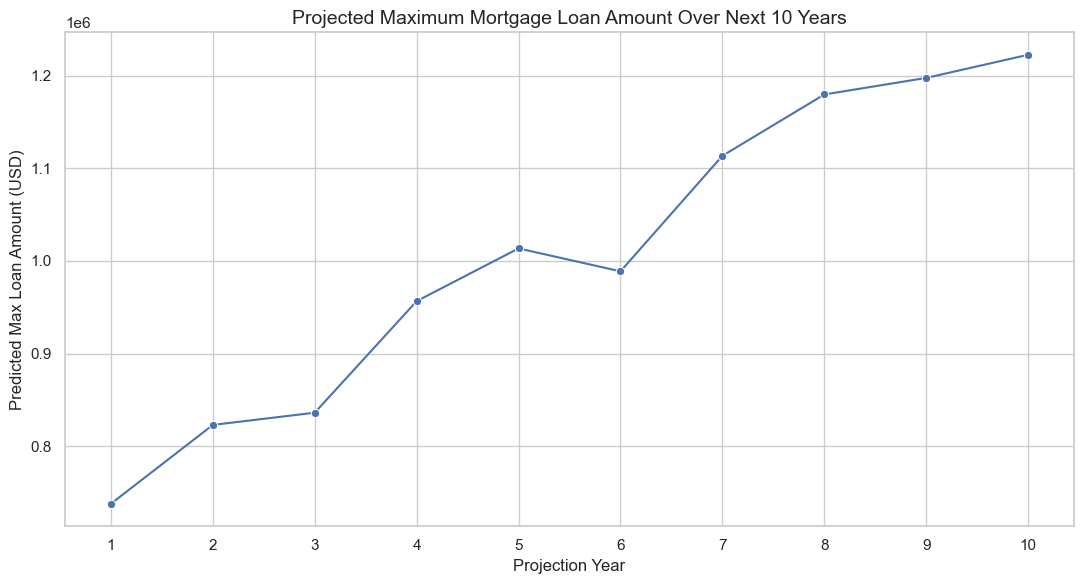

In [85]:
# Plot predicted max loan amount over 10 years

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=projection_df,
    x="Projection Year",
    y="Predicted Max Loan Amount (USD)",
    marker="o"
)

plt.title("Projected Maximum Mortgage Loan Amount Over Next 10 Years", fontsize=14)
plt.xlabel("Projection Year")
plt.ylabel("Predicted Max Loan Amount (USD)")
plt.xticks(projection_df["Projection Year"])
plt.tight_layout()
plt.savefig(PLOTS_DIR / "22_user_10_year_loan_capacity_projection.png", dpi=300)
plt.show()

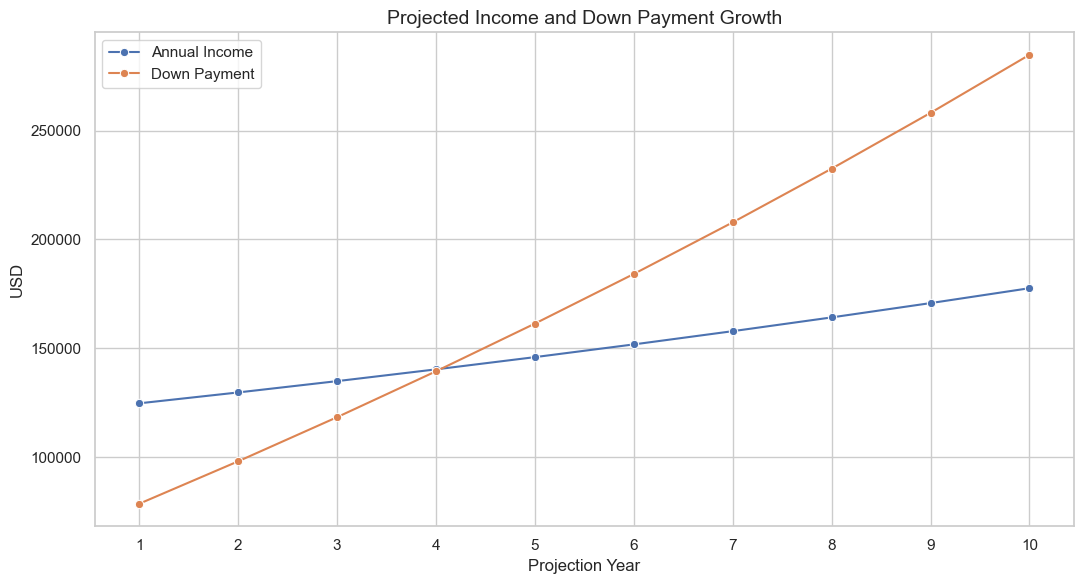

In [86]:
# Plot annual income and down payment growth
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=projection_df,
    x="Projection Year",
    y="Annual Income (USD)",
    marker="o",
    label="Annual Income"
)

sns.lineplot(
    data=projection_df,
    x="Projection Year",
    y="Down Payment (USD)",
    marker="o",
    label="Down Payment"
)

plt.title("Projected Income and Down Payment Growth", fontsize=14)
plt.xlabel("Projection Year")
plt.ylabel("USD")
plt.xticks(projection_df["Projection Year"])
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "23_income_down_payment_projection.png", dpi=300)
plt.show()

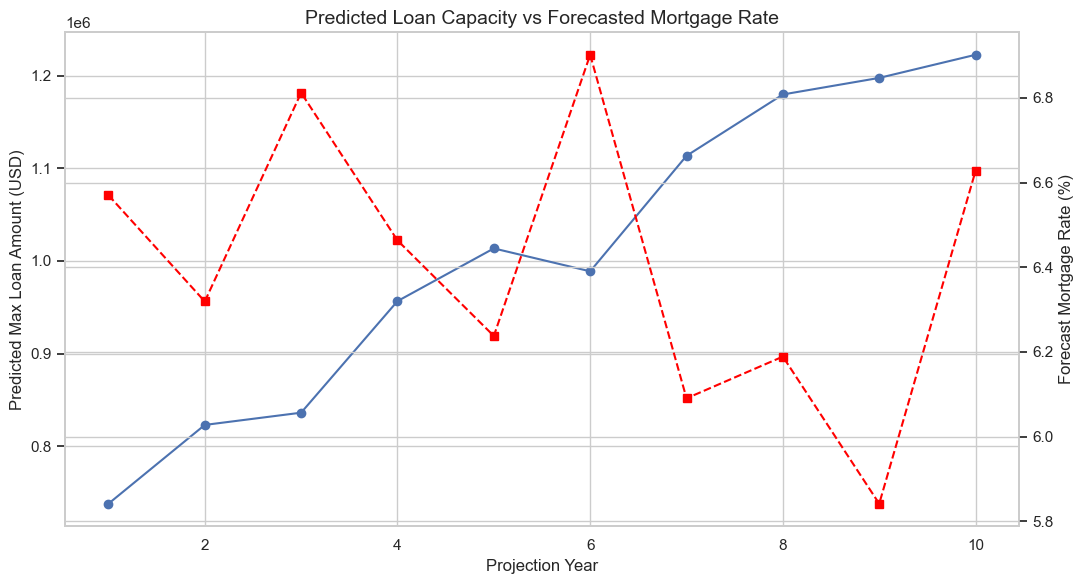

In [87]:
# Plot forecasted mortgage rate and predicted max loan amount together
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(
    projection_df["Projection Year"],
    projection_df["Predicted Max Loan Amount (USD)"],
    marker="o",
    label="Predicted Max Loan Amount"
)

ax1.set_xlabel("Projection Year")
ax1.set_ylabel("Predicted Max Loan Amount (USD)")

ax2 = ax1.twinx()

ax2.plot(
    projection_df["Projection Year"],
    projection_df["Forecast Mortgage Rate (%)"],
    marker="s",
    linestyle="--",
    color="red",
    label="Forecast Mortgage Rate"
)

ax2.set_ylabel("Forecast Mortgage Rate (%)")

plt.title("Predicted Loan Capacity vs Forecasted Mortgage Rate", fontsize=14)

fig.tight_layout()
plt.savefig(PLOTS_DIR / "24_loan_capacity_vs_mortgage_rate.png", dpi=300)
plt.show()

## Interpretation

In [88]:
# Calculate projection changes

initial_projected_loan = projection_df.iloc[0]["Predicted Max Loan Amount (USD)"]
final_projected_loan = projection_df.iloc[-1]["Predicted Max Loan Amount (USD)"]

absolute_change = final_projected_loan - initial_projected_loan
percentage_change = absolute_change / initial_projected_loan * 100

initial_rate = projection_df.iloc[0]["Forecast Mortgage Rate (%)"]
final_rate = projection_df.iloc[-1]["Forecast Mortgage Rate (%)"]

initial_income = projection_df.iloc[0]["Annual Income (USD)"]
final_income = projection_df.iloc[-1]["Annual Income (USD)"]

initial_down_payment = projection_df.iloc[0]["Down Payment (USD)"]
final_down_payment = projection_df.iloc[-1]["Down Payment (USD)"]

summary_df = pd.DataFrame({
    "Metric": [
        "Initial Predicted Max Loan",
        "Final Predicted Max Loan",
        "Absolute Change",
        "Percentage Change",
        "Initial Forecast Mortgage Rate",
        "Final Forecast Mortgage Rate",
        "Initial Annual Income",
        "Final Annual Income",
        "Initial Down Payment",
        "Final Down Payment"
    ],
    "Value": [
        initial_projected_loan,
        final_projected_loan,
        absolute_change,
        percentage_change,
        initial_rate,
        final_rate,
        initial_income,
        final_income,
        initial_down_payment,
        final_down_payment
    ]
})

summary_df

,Metric,Value
0,Initial Predicted Max Loan,"737,900.20"
1,Final Predicted Max Loan,"1,222,548.31"
2,Absolute Change,"484,648.11"
3,Percentage Change,65.68
4,Initial Forecast Mortgage Rate,6.57
5,Final Forecast Mortgage Rate,6.63
6,Initial Annual Income,"124,800.00"
7,Final Annual Income,"177,629.31"
8,Initial Down Payment,"78,720.00"
9,Final Down Payment,"284,754.33"


In [89]:
# Save Summary
summary_output_path = REPORTS_DIR / "projection_summary.csv"
summary_df.to_csv(summary_output_path, index=False)
print(f"Projection summary saved to: {summary_output_path}")

Projection summary saved to: outputs/projection_reports/projection_summary.csv


In [90]:
# Generate a written projection interpretation
projection_interpretation = f"""
# 10-Year Borrowing Capacity Projection Summary

The trained model was used to estimate the user's maximum mortgage loan amount over a 10-year period.

## User Financial Assumptions

- Annual income growth rate: {future_assumptions["annual_income_growth_rate"] * 100:.2f}%
- Annual savings rate toward down payment: {future_assumptions["savings_rate_for_down_payment"] * 100:.2f}%
- Annual monthly-debt growth rate: {future_assumptions["annual_monthly_debt_growth_rate"] * 100:.2f}%
- Annual credit score change: {future_assumptions["annual_credit_score_change"]:.1f} points
- Additional loans repaid per year: {future_assumptions["additional_loans_repaid_per_year"]:.1f}

## Projection Result

The predicted maximum loan amount changed from:

${initial_projected_loan:,.2f}

in projection year 1 to:

${final_projected_loan:,.2f}

in projection year 10.

This represents an absolute change of:

${absolute_change:,.2f}

or:

{percentage_change:.2f}%

over the 10-year projection period.

## Interest Rate Scenario

The forecasted mortgage rate changed from:

{initial_rate:.2f}%

in projection year 1 to:

{final_rate:.2f}%

in projection year 10.

## Interpretation

The projection reflects the combined impact of borrower financial growth and changing mortgage-rate conditions. If the user's income and down payment increase over time, borrowing capacity may improve. However, higher mortgage rates can reduce affordability and partially offset the benefits of income and savings growth.

This result should be interpreted as a planning scenario, not a guaranteed lending outcome.
"""

interpretation_path = REPORTS_DIR / "projection_interpretation.md"

interpretation_path.write_text(projection_interpretation)

print(projection_interpretation)
print(f"\nProjection interpretation saved to: {interpretation_path}")


# 10-Year Borrowing Capacity Projection Summary

The trained model was used to estimate the user's maximum mortgage loan amount over a 10-year period.

## User Financial Assumptions

- Annual income growth rate: 4.00%
- Annual savings rate toward down payment: 15.00%
- Annual monthly-debt growth rate: 0.00%
- Annual credit score change: 3.0 points
- Additional loans repaid per year: 0.0

## Projection Result

The predicted maximum loan amount changed from:

$737,900.20

in projection year 1 to:

$1,222,548.31

in projection year 10.

This represents an absolute change of:

$484,648.11

or:

65.68%

over the 10-year projection period.

## Interest Rate Scenario

The forecasted mortgage rate changed from:

6.57%

in projection year 1 to:

6.63%

in projection year 10.

## Interpretation

The projection reflects the combined impact of borrower financial growth and changing mortgage-rate conditions. If the user's income and down payment increase over time, borrowing capacity may improve. 

## Summary

This notebook completed the final project extension.

Completed tasks:

- Loaded the trained mortgage loan prediction model from Notebook 2
- Loaded historical 30-year fixed mortgage-rate data
- Cleaned and visualized the mortgage-rate time series
- Resampled weekly mortgage rates into monthly averages
- Built a rolling average baseline and Exponential Smoothing central trend
- Created a fluctuating mortgage-rate forecast path using historical month-to-month rate changes
- Converted the selected monthly forecast into 10 annual projection periods
- Collected user borrower information and future financial assumptions
- Projected user profile changes over 10 years
- Predicted maximum loan amount for each future year
- Visualized the user's 10-year borrowing capacity trend
- Saved forecast, projection, summary, and interpretation outputs
